In [3]:
import pandas as pd 
import numpy as np 
from scipy import stats
import matplotlib.pyplot as plt 

### Exercise 14.1

In [2]:
df_ex01 = pd.DataFrame({
    'zinc_added': [0.102,0.213,0.306,0.407,0.511,0.602],
    'zinc_found': [0.097,0.207,0.300,0.393,0.502,0.613]
})
df_ex01

,zinc_added,zinc_found
0,0.102,0.097
1,0.213,0.207
2,0.306,0.300
3,0.407,0.393
4,0.511,0.502
5,0.602,0.613


In [3]:
np.polyfit(df_ex01['zinc_added'], df_ex01['zinc_found'], 1)

array([ 1.01746344, -0.01106487])

In [4]:
df_ex01['xy'] = df_ex01.iloc[:,:2].prod(axis=1)
df_ex01

,zinc_added,zinc_found,xy
0,0.102,0.097,0.009894
1,0.213,0.207,0.044091
2,0.306,0.300,0.091800
3,0.407,0.393,0.159951
4,0.511,0.502,0.256522
5,0.602,0.613,0.369026


In [5]:
df_ex01['x2'] = df_ex01.zinc_added**2
df_ex01

,zinc_added,zinc_found,xy,x2
0,0.102,0.097,0.009894,0.010404
1,0.213,0.207,0.044091,0.045369
2,0.306,0.300,0.091800,0.093636
3,0.407,0.393,0.159951,0.165649
4,0.511,0.502,0.256522,0.261121
5,0.602,0.613,0.369026,0.362404


In [6]:
b_ex01 = df_ex01['xy'].sum()/df_ex01['x2'].sum()
b_ex01

np.float64(0.9922233835473262)

In [7]:
df_ex01['y_hat'] = df_ex01.zinc_added * b_ex01
df_ex01

,zinc_added,zinc_found,xy,x2,y_hat
0,0.102,0.097,0.009894,0.010404,0.101207
1,0.213,0.207,0.044091,0.045369,0.211344
2,0.306,0.300,0.091800,0.093636,0.303620
3,0.407,0.393,0.159951,0.165649,0.403835
4,0.511,0.502,0.256522,0.261121,0.507026
5,0.602,0.613,0.369026,0.362404,0.597318


In [8]:
df_ex01['residual'] = df_ex01.zinc_found - df_ex01.y_hat
df_ex01

,zinc_added,zinc_found,xy,x2,y_hat,residual
0,0.102,0.097,0.009894,0.010404,0.101207,-0.004207
1,0.213,0.207,0.044091,0.045369,0.211344,-0.004344
2,0.306,0.300,0.091800,0.093636,0.303620,-0.003620
3,0.407,0.393,0.159951,0.165649,0.403835,-0.010835
4,0.511,0.502,0.256522,0.261121,0.507026,-0.005026
5,0.602,0.613,0.369026,0.362404,0.597318,0.015682


In [9]:
v_hat_b_ex01 = (df_ex01.residual**2).sum()/(6-1) # 5 degree of freedom = 6 data points - 1 parameter analyzed
v_hat_b_ex01

np.float64(8.764769530238676e-05)

In [10]:
b_ex01, np.sqrt(v_hat_b_ex01)

(np.float64(0.9922233835473262), np.float64(0.009362034784296988))

### Exercise 14.2

In [11]:
df_ex02 = pd.DataFrame({
    'x': [8,22,35,40,57,73,78,87,98],
    'y': [6.16,9.88,14.35,24.06,30.34,32.17,42.18,43.23,48.76]
})

df_ex02['new_y'] = df_ex02.y + 5
df_ex02

,x,y,new_y
0,8,6.16,11.16
1,22,9.88,14.88
2,35,14.35,19.35
3,40,24.06,29.06
4,57,30.34,35.34
5,73,32.17,37.17
6,78,42.18,47.18
7,87,43.23,48.23
8,98,48.76,53.76


In [12]:
b_ex02 = df_ex02[['x', 'y']].prod(axis=1).sum() / (df_ex02['x']**2).sum()
b_ex02

np.float64(0.5009830152238128)

In [13]:
b_ex02_new = df_ex02[['x', 'new_y']].prod(axis=1).sum() / (df_ex02['x']**2).sum()
b_ex02_new

np.float64(0.5717055782776642)

In [14]:
df_ex02['y_hat'] = df_ex02['x'] * b_ex02
df_ex02['new_y_hat'] = df_ex02['x'] * b_ex02_new
df_ex02['residual'] = df_ex02['y'] - df_ex02['y_hat']
df_ex02['residual_new'] = df_ex02['new_y'] - df_ex02['new_y_hat']
df_ex02

,x,y,new_y,y_hat,new_y_hat,residual,residual_new
0,8,6.16,11.16,4.007864,4.573645,2.152136,6.586355
1,22,9.88,14.88,11.021626,12.577523,-1.141626,2.302477
2,35,14.35,19.35,17.534406,20.009695,-3.184406,-0.659695
3,40,24.06,29.06,20.039321,22.868223,4.020679,6.191777
4,57,30.34,35.34,28.556032,32.587218,1.783968,2.752782
5,73,32.17,37.17,36.571760,41.734507,-4.401760,-4.564507
6,78,42.18,47.18,39.076675,44.593035,3.103325,2.586965
7,87,43.23,48.23,43.585522,49.738385,-0.355522,-1.508385
8,98,48.76,53.76,49.096335,56.027147,-0.336335,-2.267147


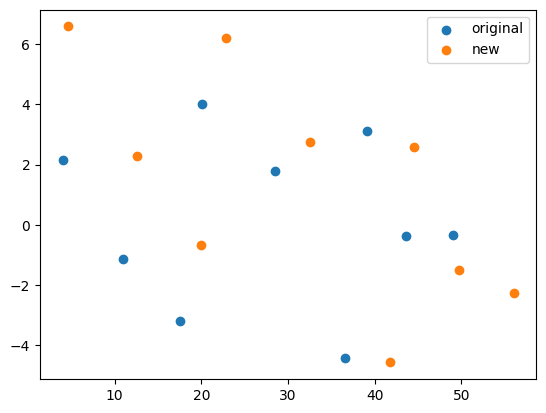

In [15]:
plt.scatter(df_ex02['y_hat'], df_ex02['residual'], label='original')
plt.scatter(df_ex02['new_y_hat'], df_ex02['residual_new'], label='new')
plt.legend()

### Exercise 14.4

In [16]:
df_ex04 = pd.DataFrame({
    'x': [2.00,2.50,2.50,2.75,3.00,3.00,3.00],
    'y': [89,97,91,98,100,104,97]
})

df_ex04

,x,y
0,2.00,89
1,2.50,97
2,2.50,91
3,2.75,98
4,3.00,100
5,3.00,104
6,3.00,97


In [17]:
se2_ex04 = (df_ex04[df_ex04['x']==2.50]['y'].var(ddof=1) + df_ex04[df_ex04['x']==3.00]['y'].var(ddof=1)*2) / 3 # mean squares over total degree of freedom
se_ex04 = np.sqrt(se2_ex04)
se2_ex04, se_ex04

(np.float64(14.222222222222221), np.float64(3.7712361663282534))

In [18]:
df_ex04['x_bar'] = df_ex04['x'].mean()
df_ex04['y_bar'] = df_ex04['y'].mean()
df_ex04['x-x_bar'] = df_ex04['x'] - df_ex04['x_bar']
df_ex04['y-y_bar'] = df_ex04['y'] - df_ex04['y_bar']
df_ex04

,x,y,x_bar,y_bar,x-x_bar,y-y_bar
0,2.00,89,2.678571,96.571429,-0.678571,-7.571429
1,2.50,97,2.678571,96.571429,-0.178571,0.428571
2,2.50,91,2.678571,96.571429,-0.178571,-5.571429
3,2.75,98,2.678571,96.571429,0.071429,1.428571
4,3.00,100,2.678571,96.571429,0.321429,3.428571
5,3.00,104,2.678571,96.571429,0.321429,7.428571
6,3.00,97,2.678571,96.571429,0.321429,0.428571


In [19]:
b1_ex04 = (df_ex04['x-x_bar'] * df_ex04['y-y_bar']).sum() / (df_ex04['x-x_bar']**2).sum()
b0_ex04 = df_ex04.loc[0,'y_bar'] - b1_ex04 * df_ex04.loc[0,'x_bar']
b1_ex04, b0_ex04

(np.float64(11.659574468085106), np.float64(65.34042553191489))

In [20]:
df_ex04['y_hat'] = b0_ex04 + b1_ex04 * df_ex04['x']
df_ex04

,x,y,x_bar,y_bar,x-x_bar,y-y_bar,y_hat
0,2.00,89,2.678571,96.571429,-0.678571,-7.571429,88.659574
1,2.50,97,2.678571,96.571429,-0.178571,0.428571,94.489362
2,2.50,91,2.678571,96.571429,-0.178571,-5.571429,94.489362
3,2.75,98,2.678571,96.571429,0.071429,1.428571,97.404255
4,3.00,100,2.678571,96.571429,0.321429,3.428571,100.319149
5,3.00,104,2.678571,96.571429,0.321429,7.428571,100.319149
6,3.00,97,2.678571,96.571429,0.321429,0.428571,100.319149


In [21]:
S2r_ex04 = ((df_ex04['y'] - df_ex04['y_hat'])**2).sum() # residual sum of square. capital S
S2r_ex04

np.float64(43.61702127659574)

In [22]:
S2l_ex04 = S2r_ex04 - se2_ex04 * 3
s2l_ex04 = S2l_ex04 / 2 # 2 degree of freedom (7 - 2 - 3 )
S2l_ex04, s2l_ex04 / se2_ex04

(np.float64(0.9503546099290787), np.float64(0.033410904255319174))

In [23]:
s2l_ex04 / se2_ex04

np.float64(0.033410904255319174)

### Table 14.10 14.11 14.12

In [24]:
df_t1410 = pd.DataFrame({
    'x': [10,10,15,20,20,25,25,25,30,35],
    'y': [73,78,85,90,91,87,86,91,75,65]
})

df_t1410

,x,y
0,10,73
1,10,78
2,15,85
3,20,90
4,20,91
5,25,87
6,25,86
7,25,91
8,30,75
9,35,65


In [25]:
df_t1410['ave'] = df_t1410['y'].mean()
df_t1410

,x,y,ave
0,10,73,82.1
1,10,78,82.1
2,15,85,82.1
3,20,90,82.1
4,20,91,82.1
5,25,87,82.1
6,25,86,82.1
7,25,91,82.1
8,30,75,82.1
9,35,65,82.1


In [26]:
b1_t1410, b0_t1410 = np.polyfit(df_t1410['x'], df_t1410['y'], 1)

In [27]:
df_t1410['y_hat'] = b1_t1410 * df_t1410['x'] + b0_t1410

In [28]:
(df_t1410['ave']**2).sum() # sum of square from mean

np.float64(67404.09999999999)

In [29]:
df_t1410['residual'] = df_t1410['y'] - df_t1410['y_hat']

In [30]:
(df_t1410['y']**2).sum() # total sum of squares

np.int64(68115)

In [31]:
(df_t1410['residual']**2).sum() # sum of squares from residuals

np.float64(686.3983402489625)

In [32]:
(df_t1410['y_hat']**2).sum() # sum of squares from y_hat (expctations / predictions)

np.float64(67428.60165975099)

In [33]:
# sum of squares from pure error from replicates, total degree of freedom = 1 +1 +2
df_t1410[df_t1410['x']==10]['y'].var(ddof=1) *1 + df_t1410[df_t1410['x']==20]['y'].var(ddof=1) *1 + df_t1410[df_t1410['x']==25]['y'].var(ddof=1) *2

np.float64(27.0)

In [34]:
# sum of sqaures from lack of fit. total degree of freedom = 10-2(2 parameters)-4(df of pure error)
686.4-27

659.4

In [36]:
# f score
659.4/27.0

24.42222222222222

In [37]:
df_t1410

,x,y,ave,y_hat,residual
0,10,73,82.1,84.419087,-11.419087
1,10,78,82.1,84.419087,-6.419087
2,15,85,82.1,83.410788,1.589212
3,20,90,82.1,82.402490,7.597510
4,20,91,82.1,82.402490,8.597510
5,25,87,82.1,81.394191,5.605809
6,25,86,82.1,81.394191,4.605809
7,25,91,82.1,81.394191,9.605809
8,30,75,82.1,80.385892,-5.385892
9,35,65,82.1,79.377593,-14.377593


In [39]:
b2_2_t1410, b1_2_t1410, b0_2_t1410 = np.polyfit(df_t1410['x'], df_t1410['y'], 2)
df_t1410['y_hat_2'] = b2_2_t1410 * df_t1410['x']**2 + b1_2_t1410 * df_t1410['x'] + b0_2_t1410
df_t1410

,x,y,ave,y_hat,residual,y_hat_2
0,10,73,82.1,84.419087,-11.419087,75.518987
1,10,78,82.1,84.419087,-6.419087,75.518987
2,15,85,82.1,83.410788,1.589212,85.874209
3,20,90,82.1,82.402490,7.597510,89.845728
4,20,91,82.1,82.402490,8.597510,89.845728
5,25,87,82.1,81.394191,5.605809,87.433544
6,25,86,82.1,81.394191,4.605809,87.433544
7,25,91,82.1,81.394191,9.605809,87.433544
8,30,75,82.1,80.385892,-5.385892,78.637658
9,35,65,82.1,79.377593,-14.377593,63.458070


In [40]:
df_t1410['residual_2'] = df_t1410['y'] - df_t1410['y_hat_2']
df_t1410

,x,y,ave,y_hat,residual,y_hat_2,residual_2
0,10,73,82.1,84.419087,-11.419087,75.518987,-2.518987
1,10,78,82.1,84.419087,-6.419087,75.518987,2.481013
2,15,85,82.1,83.410788,1.589212,85.874209,-0.874209
3,20,90,82.1,82.402490,7.597510,89.845728,0.154272
4,20,91,82.1,82.402490,8.597510,89.845728,1.154272
5,25,87,82.1,81.394191,5.605809,87.433544,-0.433544
6,25,86,82.1,81.394191,4.605809,87.433544,-1.433544
7,25,91,82.1,81.394191,9.605809,87.433544,3.566456
8,30,75,82.1,80.385892,-5.385892,78.637658,-3.637658
9,35,65,82.1,79.377593,-14.377593,63.458070,1.541930


In [41]:
S2r_2_t1410 = (df_t1410['residual_2']**2).sum()
S2r_2_t1410

np.float64(45.19382911392411)

In [43]:
(S2r_2_t1410-27)/3 / (27/4)

np.float64(0.8984606969839066)

### Appendix 14B

In [49]:
X_A14B = pd.DataFrame({
    'x0': [1]*10,
    'x': [10,10,15,20,20,25,25,25,30,35],
})
X_A14B['x^2'] = X_A14B['x']**2
X_A14B_arr = np.array(X_A14B)

In [50]:
y_A14B = pd.DataFrame({
    'y': [73,78,85,90,91,87,86,91,75,65]
})
y_A14B_arr = np.array(y)

In [ ]:
X_A14B_arr.T.dot(X_A14B_arr)

array([[     10,     215,    5225],
       [    215,    5225,  138125],
       [   5225,  138125, 3873125]])

In [54]:
X_A14B_arr.T.dot(y_A14B_arr)

array([[   821],
       [ 17530],
       [418750]])

In [60]:
np.linalg.inv(X_A14B_arr.T.dot(X_A14B_arr)).dot(X_A14B_arr.T.dot(y_A14B_arr))

array([[35.65743671],
       [ 5.26289557],
       [-0.12767405]])

### Appendix 14C

In [ ]:
X_A14C_arr = np.array([-1,-0.7,-1,1,-0.5,-1,-1,1.3,-1,1,0.9,-1,-0.6,-0.9,1,1,-1.1,1,-1,1,1,1,1.6,1]).reshape(8,3)
X_A14C_arr

array([[-1. , -0.7, -1. ],
       [ 1. , -0.5, -1. ],
       [-1. ,  1.3, -1. ],
       [ 1. ,  0.9, -1. ],
       [-0.6, -0.9,  1. ],
       [ 1. , -1.1,  1. ],
       [-1. ,  1. ,  1. ],
       [ 1. ,  1.6,  1. ]])

In [82]:
X_A14C_arr = np.concat((np.array([1,1,1,1,1,1,1,1]).reshape(8,1), X_A14C_arr),axis=1)

In [64]:
y_A14C_arr = np.array([55.7,56.7,61.4,64.2,45.9,48.7,53.9,59.0]).reshape(8,1)
y_A14C_arr

array([[55.7],
       [56.7],
       [61.4],
       [64.2],
       [45.9],
       [48.7],
       [53.9],
       [59. ]])

In [86]:
np.linalg.inv(X_A14C_arr.T.dot(X_A14C_arr)).dot(X_A14C_arr.T.dot(y_A14C_arr))

array([[54.83118345],
       [ 1.39009467],
       [ 3.93405906],
       [-3.68530178]])

### Appendix 14C

In [1]:
def yates_algor(pd_serie, n):
    '''
    pd_serie: results in the correct order according to Yates algorithm
    n: number of iterations
    '''
    for i in range(n):
        # print(pd_serie)
        index_1 = pd_serie.index[::2]
        index_2 = pd_serie.index[1::2]
        serie_1 = pd_serie[index_1].reset_index(drop=True) + pd_serie[index_2].reset_index(drop=True)
        serie_2 = -pd_serie[index_1].reset_index(drop=True) + pd_serie[index_2].reset_index(drop=True)
        pd_serie = pd.concat((serie_1, serie_2)).reset_index(drop=True)

    pd_serie = pd_serie / pd_serie.shape[0] * 2
    pd_serie.iloc[0] = pd_serie.iloc[0] / 2
    return pd_serie

In [4]:
df_a14c1 = pd.DataFrame({
    'x1':[(-1)**(i//1+1) for i in range(8)],
    'x2':[(-1)**(i//2+1) for i in range(8)],
    'x3':[(-1)**(i//4+1) for i in range(8)],
    'resiliency': [55.7,56.7,61.4,64.2,45.9,48.7,53.9,59.0]
})

In [14]:
df_a14c2 = pd.DataFrame({
    'x1': [-1,1,-1,1,-0.6,1,-1,1],
    'x2': [-0.7,-0.5,1.3,0.9,-0.9,-1.1,1,1.6],
    'x3': [(-1)**(i//4+1) for i in range(8)],
    'resiliency': [55.7,56.7,61.4,64.2,45.9,48.7,53.9,59.0]
})

df_a14c2['x0'] = [1]*8

df_a14c2

,x1,x2,x3,resiliency,x0
0,-1.0,-0.7,-1,55.7,1
1,1.0,-0.5,-1,56.7,1
2,-1.0,1.3,-1,61.4,1
3,1.0,0.9,-1,64.2,1
4,-0.6,-0.9,1,45.9,1
5,1.0,-1.1,1,48.7,1
6,-1.0,1.0,1,53.9,1
7,1.0,1.6,1,59.0,1


In [17]:
factors = [f'x{j}' for j in range(0,4)]
for i in factors:
    print(df_a14c2[factors].mul(df_a14c2[i], axis=0).sum(axis=0))



x0    8.0
x1    0.4
x2    1.6
x3    0.0
dtype: float64
x0    0.40
x1    7.36
x2   -0.16
x3    0.40
dtype: float64
x0    1.60
x1   -0.16
x2    8.82
x3   -0.40
dtype: float64
x0    0.0
x1    0.4
x2   -0.4
x3    8.0
dtype: float64
